## Step 3: Extracting Motor Imagery Events
We extract the labeled time segments (epochs) from the filtered EEG.
- T0 = Rest
- T1 = Left fist imagination
- T2 = Right fist imagination

In [2]:
import mne
import numpy as np

# Load the filtered data we saved earlier
raw_filtered = mne.io.read_raw_fif(
    '../outputs/filtered_data/S001R03_filtered_raw.fif', 
    preload=True
)
print("Filtered data loaded!")

Opening raw data file ../outputs/filtered_data/S001R03_filtered_raw.fif...
Isotrak not found
    Range : 0 ... 19999 =      0.000 ...   124.994 secs
Ready.
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtered data loaded!


In [4]:
# Extract events from the data
events, event_id = mne.events_from_annotations(raw_filtered)
print("Event IDs:", event_id)
print("Total events found:", len(events))
print("First 10 events:", events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event IDs: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events found: 30
First 10 events: [[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


## Creating Epochs
We cut the continuous EEG into small time windows around each event.
Each epoch is 4 seconds long — capturing the brain activity during each task.

In [5]:
# Define which events we want
event_id_dict = {
    'rest': 1,
    'left_fist': 2,
    'right_fist': 3
}
# Cut the data into epochs — 4 seconds per event
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id_dict,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True
)
print(epochs)
print("Number of epochs per class:")
print("Rest:", len(epochs['rest']))
print("Left fist:", len(epochs['left_fist']))
print("Right fist:", len(epochs['right_fist']))

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~9.5 MB, data loaded,
 'rest': 15
 'left_fist': 8
 'right_fist': 7>
Number of epochs per class:
Rest: 15
Left fist: 8
Right fist: 7


In [6]:
# Save epochs for use in classification later
epochs.save('../outputs/filtered_data/S001R03_epochs-epo.fif', overwrite=True)
print("Epochs saved!")

Epochs saved!


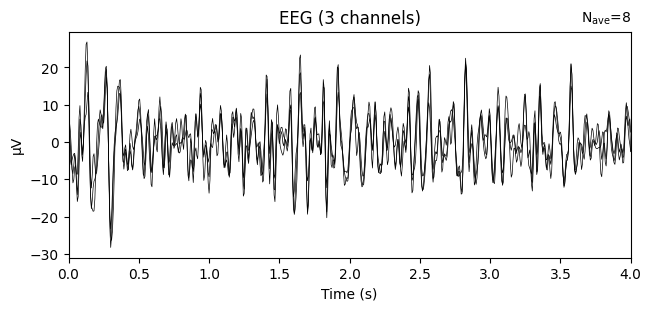

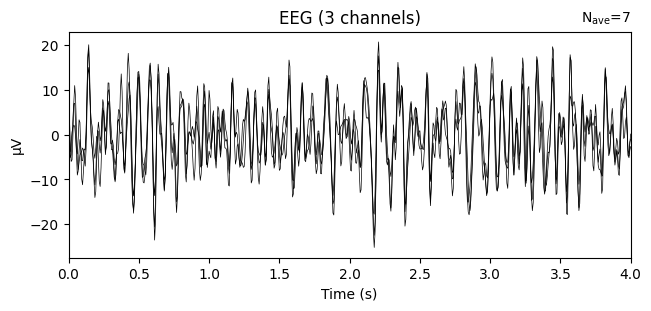

In [9]:
# Plot average brain response for left vs right fist
fig = epochs['left_fist'].average().plot(
    picks=['C3..', 'C4..', 'Cz..'],
    show=True
)
fig2 = epochs['right_fist'].average().plot(
    picks=['C3..', 'C4..', 'Cz..'],
    show=True
)

The two plots look slightly different in pattern — that difference is exactly what the SVM classifier will learn to detect. Right now it's hard to see with only 8 and 7 epochs — which is why next we combine all 3 runs (R03, R07, R11) to get more data.

In [10]:
fig.savefig('../outputs/plots/avg_left_fist.png')
fig2.savefig('../outputs/plots/avg_right_fist.png')